# Project 6: Text Classification with RNN/LSTM

Building a bidirectional LSTM to classify IMDB movie reviews as positive or negative sentiment.

**Concepts Covered:**
- RNN and LSTM architecture for sequence processing
- Text tokenization and vocabulary building
- Word embeddings (`nn.Embedding`)
- Bidirectional LSTM
- Sequence padding for variable-length inputs
- Custom Dataset and collate function
- Gradient clipping for RNN stability

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import re
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
Using device: cuda
GPU: Tesla T4


---
## Phase 1: Understanding the Text Pipeline

```
Text: "This movie was great"
  -> tokenize
["this", "movie", "was", "great"]
  -> vocabulary lookup
[45, 123, 8, 567]
  -> nn.Embedding
[[0.2, -0.1, ...], [0.8, 0.3, ...], [0.1, 0.4, ...], [0.6, 0.9, ...]]
  -> LSTM (bidirectional)
Forward + Backward hidden states
  -> Classifier
0.87 -> Positive!
```

**Why LSTM over basic RNN?**

Basic RNN forgets early words in long sequences (vanishing gradient problem). LSTM has gates (forget, input, output) that control what to remember and forget.

---
## Phase 2: Load and Process IMDB Dataset

In [3]:
# Load IMDB dataset from Hugging Face
dataset = load_dataset("imdb")
print(dataset)
print(f"\nTrain samples: {len(dataset['train'])}")
print(f"Test samples: {len(dataset['test'])}")
print(f"\nSample:")
print(f"  Label: {dataset['train'][0]['label']} (0=Negative, 1=Positive)")
print(f"  Text preview: {dataset['train'][0]['text'][:200]}...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Train samples: 25000
Test samples: 25000

Sample:
  Label: 0 (0=Negative, 1=Positive)
  Text preview: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...


In [4]:
# Simple tokenizer
def simple_tokenizer(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

# Build vocabulary from training data
print("Building vocabulary...")
counter = Counter()
for sample in dataset['train']:
    counter.update(simple_tokenizer(sample['text']))

# Keep top 25000 most common words
vocab_list = ['<pad>', '<unk>'] + [word for word, count in counter.most_common(25000)]
word2idx = {word: idx for idx, word in enumerate(vocab_list)}

VOCAB_SIZE = len(word2idx)
PAD_IDX = word2idx['<pad>']
UNK_IDX = word2idx['<unk>']

print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"\nSample tokenization:")
sample = 'This movie was absolutely fantastic!'
tokens = simple_tokenizer(sample)
indices = [word2idx.get(token, UNK_IDX) for token in tokens]
print(f"  Text: {sample}")
print(f"  Tokens: {tokens}")
print(f"  Indices: {indices}")

Building vocabulary...
Vocabulary size: 25002

Sample tokenization:
  Text: This movie was absolutely fantastic!
  Tokens: ['this', 'movie', 'was', 'absolutely', 'fantastic']
  Indices: [11, 18, 14, 412, 759]


In [5]:
# Custom Dataset
class IMDBDataset(Dataset):
    def __init__(self, split='train', max_length=256):
        self.data = []
        hf_data = dataset[split]

        for sample in hf_data:
            tokens = simple_tokenizer(sample['text'])[:max_length]
            indices = [word2idx.get(token, UNK_IDX) for token in tokens]
            if len(indices) > 0:
                label = sample['label']
                self.data.append((torch.tensor(indices), label))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# Collate function — pads sequences in a batch to same length
def collate_fn(batch):
    texts, labels = zip(*batch)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=PAD_IDX)
    labels = torch.tensor(labels, dtype=torch.float32)
    return texts_padded, labels

print("Loading datasets...")
train_dataset = IMDBDataset(split='train', max_length=256)
test_dataset = IMDBDataset(split='test', max_length=256)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

sample_text, sample_label = train_dataset[0]
print(f"\nSample review length: {len(sample_text)} tokens")
print(f"Sample label: {'Positive' if sample_label == 1 else 'Negative'}")

Loading datasets...
Train samples: 25000
Test samples: 25000

Sample review length: 256 tokens
Sample label: Negative


---
## Define LSTM Model

### Architecture
```
Word indices -> Embedding (128-dim) -> Bidirectional LSTM (2 layers)
  -> Concatenate forward + backward hidden states (256-dim)
  -> Linear(256, 128) -> ReLU -> Dropout -> Linear(128, 1) -> Sigmoid
```

In [6]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, pad_idx, dropout=0.3):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)

        hidden_forward = hidden[-2]
        hidden_backward = hidden[-1]
        combined = torch.cat((hidden_forward, hidden_backward), dim=1)

        output = self.classifier(combined)
        output = self.sigmoid(output).squeeze(1)
        return output

# Hyperparameters
EMBEDDING_DIM = 128
HIDDEN_DIM = 128
NUM_LAYERS = 2

model = SentimentLSTM(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, PAD_IDX).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

SentimentLSTM(
  (embedding): Embedding(25002, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
  (sigmoid): Sigmoid()
)

Total parameters: 3,892,737


In [7]:
# Loss, optimizer, scheduler
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

In [8]:
# Training loop
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []
best_test_acc = 0.0

num_epochs = 10

for epoch in range(num_epochs):
    start_time = time.time()

    # Training
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for batch_text, batch_labels in train_loader:
        batch_text = batch_text.to(device)
        batch_labels = batch_labels.to(device)

        outputs = model(batch_text)
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * batch_text.size(0)
        predicted = (outputs >= 0.5).float()
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total

    # Evaluation
    model.eval()
    running_test_loss, correct_test, total_test = 0.0, 0, 0

    with torch.no_grad():
        for batch_text, batch_labels in test_loader:
            batch_text = batch_text.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_text)
            loss = criterion(outputs, batch_labels)

            running_test_loss += loss.item() * batch_text.size(0)
            predicted = (outputs >= 0.5).float()
            total_test += batch_labels.size(0)
            correct_test += (predicted == batch_labels).sum().item()

    test_loss = running_test_loss / total_test
    test_acc = correct_test / total_test

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    scheduler.step(test_loss)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), "best_lstm_model.pth")

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Loss: {train_loss:.4f} | Time: {elapsed:.1f}s")

print(f"\nBest Test Accuracy: {best_test_acc:.4f}")

Epoch  1/10 | Train Acc: 0.5548 | Test Acc: 0.5777 | Loss: 0.6812 | Time: 17.5s
Epoch  2/10 | Train Acc: 0.6622 | Test Acc: 0.7497 | Loss: 0.6097 | Time: 16.4s
Epoch  3/10 | Train Acc: 0.8158 | Test Acc: 0.8339 | Loss: 0.4182 | Time: 16.5s
Epoch  4/10 | Train Acc: 0.8853 | Test Acc: 0.8565 | Loss: 0.2911 | Time: 17.2s
Epoch  5/10 | Train Acc: 0.9174 | Test Acc: 0.8470 | Loss: 0.2202 | Time: 16.9s
Epoch  6/10 | Train Acc: 0.9427 | Test Acc: 0.8650 | Loss: 0.1643 | Time: 17.6s
Epoch  7/10 | Train Acc: 0.9612 | Test Acc: 0.8570 | Loss: 0.1185 | Time: 18.1s
Epoch  8/10 | Train Acc: 0.9812 | Test Acc: 0.8566 | Loss: 0.0699 | Time: 18.7s
Epoch  9/10 | Train Acc: 0.9888 | Test Acc: 0.8587 | Loss: 0.0479 | Time: 18.0s
Epoch 10/10 | Train Acc: 0.9923 | Test Acc: 0.8571 | Loss: 0.0373 | Time: 17.7s

Best Test Accuracy: 0.8650


---
## Phase 3: Detailed Evaluation

In [9]:
# Load best model
model.load_state_dict(torch.load("best_lstm_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_text, batch_labels in test_loader:
        batch_text = batch_text.to(device)
        outputs = model(batch_text)
        predicted = (outputs >= 0.5).float()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_labels.numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["Negative", "Positive"]))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.85      0.86     12500
    Positive       0.85      0.88      0.87     12500

    accuracy                           0.86     25000
   macro avg       0.87      0.86      0.86     25000
weighted avg       0.87      0.86      0.86     25000



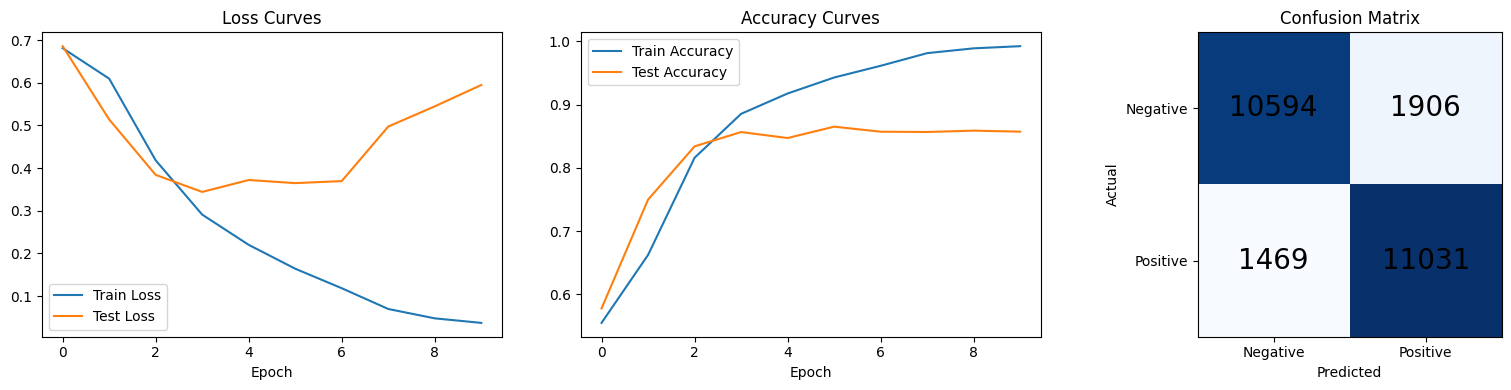

In [10]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curves
axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(test_losses, label="Test Loss")
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# Accuracy curves
axes[1].plot(train_accuracies, label="Train Accuracy")
axes[1].plot(test_accuracies, label="Test Accuracy")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].legend()

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
im = axes[2].imshow(cm, cmap="Blues")
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(["Negative", "Positive"])
axes[2].set_yticklabels(["Negative", "Positive"])
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")
axes[2].set_title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, cm[i][j], ha="center", va="center", fontsize=20)

plt.tight_layout()
plt.show()

---
## Test on Custom Reviews

In [11]:
def predict_sentiment(text, model):
    model.eval()
    tokens = simple_tokenizer(text)[:256]
    indices = torch.tensor([word2idx.get(token, UNK_IDX) for token in tokens]).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(indices)
        probability = output.item()
        sentiment = "Positive" if probability >= 0.5 else "Negative"

    return sentiment, probability

# Test custom reviews
test_reviews = [
    "This movie was absolutely fantastic! Great acting and storyline.",
    "Terrible film. Worst movie I have ever seen. Complete waste of time.",
    "The movie was okay. Nothing special but not bad either.",
    "I loved every minute of this masterpiece. A must watch!",
    "Boring and predictable. The plot made no sense at all."
]

print("Custom Review Predictions:")
print("=" * 60)
for review in test_reviews:
    sentiment, prob = predict_sentiment(review, model)
    print(f"\nReview: {review}")
    print(f"Prediction: {sentiment} (confidence: {prob:.4f})")

Custom Review Predictions:

Review: This movie was absolutely fantastic! Great acting and storyline.
Prediction: Positive (confidence: 0.9971)

Review: Terrible film. Worst movie I have ever seen. Complete waste of time.
Prediction: Negative (confidence: 0.0025)

Review: The movie was okay. Nothing special but not bad either.
Prediction: Negative (confidence: 0.0121)

Review: I loved every minute of this masterpiece. A must watch!
Prediction: Positive (confidence: 0.9987)

Review: Boring and predictable. The plot made no sense at all.
Prediction: Negative (confidence: 0.0050)


In [ ]:
# Save model
torch.save(model.state_dict(), "sentiment_lstm_final.pth")
print("Model saved!")

---
## Key Takeaways

### Text Processing Pipeline
```
Raw text -> Tokenize -> Vocabulary lookup -> Pad sequences -> Embedding -> LSTM -> Classify
```

### Concepts Learned
1. **Tokenization** — splitting text into words
2. **Vocabulary** — mapping each unique word to an integer index
3. **nn.Embedding** — converts word indices to learnable dense vectors
4. **nn.LSTM** — processes sequences maintaining long-term memory via gates
5. **Bidirectional** — reads text forward AND backward for better context
6. **Padding** — makes variable-length sequences equal length for batching
7. **Gradient Clipping** — prevents exploding gradients in RNN backpropagation
8. **Custom Dataset + collate_fn** — handles variable-length text data

### RNN vs LSTM
- RNN: simple but forgets early words in long sequences (vanishing gradient)
- LSTM: has gates (forget, input, output) to control memory — works for long text

### Architecture Comparison Across Projects
```
Tabular data  -> MLP (Project 2-3)
Images        -> CNN (Project 4-5)
Text/Sequence -> RNN/LSTM (Project 6)
All of above  -> Transformer (Project 7)
```

### Test Your Knowledge
- Why LSTM over basic RNN (vanishing gradient problem)
- How text is converted to numbers (tokenize -> vocab -> embedding)
- Why padding is needed (variable-length sequences in batches)
- Why bidirectional helps (context from both directions)
- Why gradient clipping is needed for RNNs
- Embedding layer learns word relationships during training